# Practice 8
## Guillem Moreno Garcia
## Objectives:
1. Understand the use of Gradient Boosting.
2. Understand the use of crossvalidation
3. Criterion for exploring the space of parameters
4. Be able to predict the mortality  (Total age-adjusted mortality rate per 100) and make a ranking of the data.
taken from: http://lib.stat.cmu.edu/datasets/pollution

## Explanation of the database
### Note the heterogeniety of the input variables.
This is the pollution data so loved by writers of papers on ridge regression.
Source: McDonald, G.C. and Schwing, R.C. (1973) 'Instabilities of regression
estimates relating air pollution to mortality', Technometrics, vol.15, 463-
482.

Variables in order:
* PREC   Average annual precipitation in inches
* JANT   Average January temperature in degrees F
* JULT   Same for July
* OVR65  % of 1960 SMSA population aged 65 or older
* POPN   Average household size
* EDUC   Median school years completed by those over 22
* HOUS   % of housing units which are sound & with all facilities
* DENS   Population per sq. mile in urbanized areas
* NONW   % non-white population in urbanized areas
* WWDRK  % employed in white collar occupations
* POOR   % of families with income < $3000
* HC     Relative hydrocarbon pollution potential
* NOX    Same for nitric oxides
* SO@    Same for sulphur dioxide
* HUMID  Annual average \% relative humidity at 1pm
* MORT   Total age-adjusted mortality rate per 100

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error

In [2]:
File = "pollution.txt"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename,  index_col=None,delimiter=r"\s+")
print(f'_'*50)
print(f'Shape of the database:{Data.shape}')
Data.head()


Filename with path: 
 C:\mlearn-lab\EightPractice\Data\pollution.txt
__________________________________________________
Shape of the database:(60, 16)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,y
0,36,27,71,8.1,3.34,11.4,81.5,3243,8.8,42.6,11.7,21,15,59,59,921.87
1,35,23,72,11.1,3.14,11.0,78.8,4281,3.5,50.7,14.4,8,10,39,57,997.88
2,44,29,74,10.4,3.21,9.8,81.6,4260,0.8,39.4,12.4,6,6,33,54,962.35
3,47,45,79,6.5,3.41,11.1,77.5,3125,27.1,50.2,20.6,18,8,24,56,982.29
4,43,35,77,7.6,3.44,9.6,84.6,6441,24.4,43.7,14.3,43,38,206,55,1071.29


In [3]:
ColumnName = 'PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO,HUMID,MORT'
ColumnName = ColumnName.split(',')
print( f'Size of the input vector:{len(ColumnName)-1}')

Size of the input vector:15


In [4]:
Data.columns = ColumnName
Data.head().T

,0,1,2,3,4
PREC,36.00,35.00,44.00,47.00,43.00
JANT,27.00,23.00,29.00,45.00,35.00
JULT,71.00,72.00,74.00,79.00,77.00
OVR65,8.10,11.10,10.40,6.50,7.60
POPN,3.34,3.14,3.21,3.41,3.44
EDUC,11.40,11.00,9.80,11.10,9.60
HOUS,81.50,78.80,81.60,77.50,84.60
DENS,3243.00,4281.00,4260.00,3125.00,6441.00
NONW,8.80,3.50,0.80,27.10,24.40
WWDRK,42.60,50.70,39.40,50.20,43.70


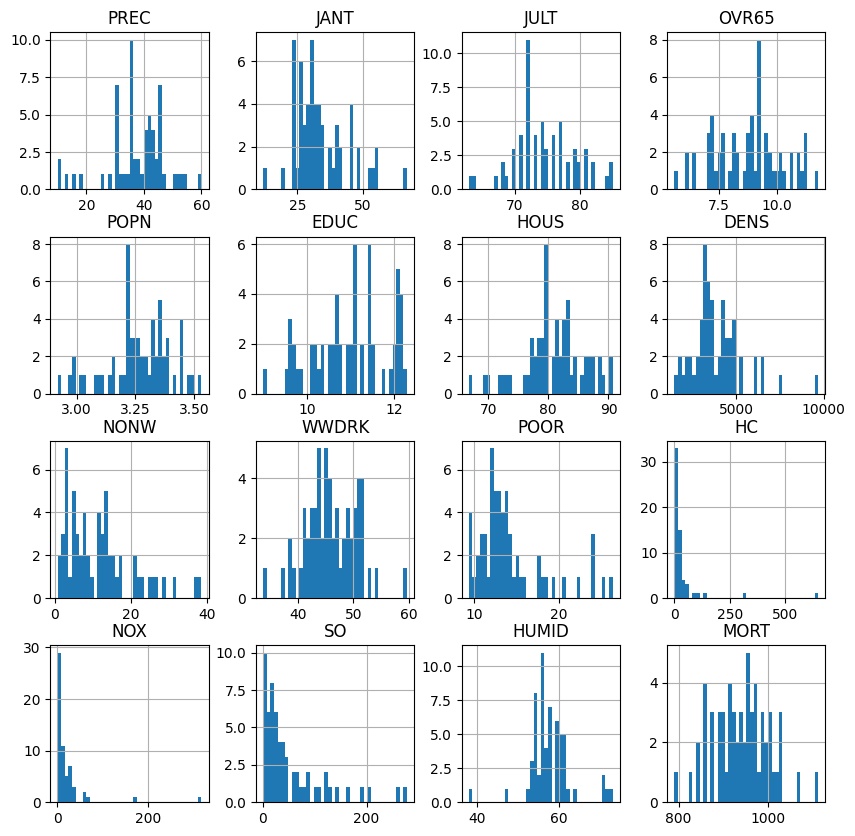

In [5]:
ax =Data.hist(figsize= (10,10),bins = 40)

## Homework: <font color='red'> Give a summary by words of the statistical distributions.</font>
## Homework: <font color='red'> Justify brifly why a Machine Learning algorithm based on linear projection might not work well with this database. (note that this includes all methods based on dot products).</font>
## Homework: <font color='red'> In case this you used linear regression, which preprocessing would you do on the data?.</font>

### Answers

1. The database is small, with only 60 observations, and the variables are very heterogeneous. Climate variables such as `PREC`, `JANT`, and `JULT` are moderate in scale, while urban density `DENS` ranges from about 1,441 to 9,699. The pollution variables `HC`, `NOX`, and `SO` are strongly right-skewed, with a few very large values. Sociological variables such as `NONW`, `POOR`, `EDUC`, and `HOUS` also show important spread. The target `MORT` is more concentrated, centered around 940 deaths per 100, but still has relevant variation from about 791 to 1,113.

2. A method based on linear projection or dot products may work poorly because the features have different units, scales, and distribution shapes. Without preprocessing, high-scale variables such as `DENS`, `HC`, `NOX`, and `SO` can dominate the dot product. The skewed variables and outliers can also pull a linear model toward a few extreme cities. In addition, the relation between mortality, pollution, climate, and social variables is probably not purely linear.

3. For linear regression I would first split the data, then fit all preprocessing only on the training set. I would standardize the features, apply transformations such as `log1p` to very skewed variables (`HC`, `NOX`, `SO`, and possibly `DENS`), check influential outliers, and use cross-validation with regularization such as Ridge or Lasso. I would also consider engineered variables that summarize pollution and socioeconomic context.

## Homework: <font color='red'> Print a simple decision tree in order to understand the dependencies of the features on the target database.</font>

Simple tree train RMSE: 26.28
Simple tree test RMSE: 55.21
|--- NONW <= 7.80
|   |--- OVR65 <= 8.50
|   |   |--- value: [831.49]
|   |--- OVR65 >  8.50
|   |   |--- NOX <= 8.50
|   |   |   |--- value: [895.55]
|   |   |--- NOX >  8.50
|   |   |   |--- value: [951.98]
|--- NONW >  7.80
|   |--- EDUC <= 11.35
|   |   |--- NONW <= 17.35
|   |   |   |--- value: [978.50]
|   |   |--- NONW >  17.35
|   |   |   |--- value: [1033.27]
|   |--- EDUC >  11.35
|   |   |--- POPN <= 3.23
|   |   |   |--- value: [881.24]
|   |   |--- POPN >  3.23
|   |   |   |--- value: [950.99]



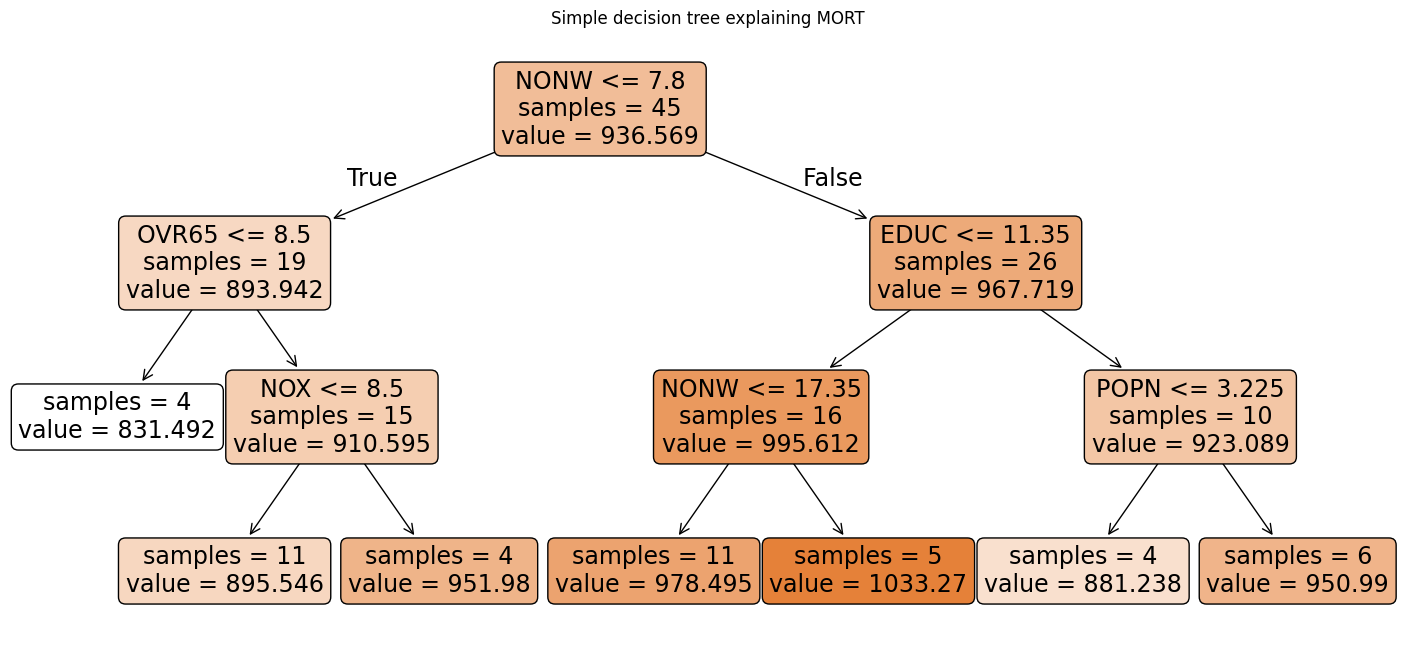

In [6]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

tree_features = ColumnName[:-1]
X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    Data[tree_features], Data['MORT'], test_size=0.25, random_state=0
)

simple_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=4, random_state=0)
simple_tree.fit(X_tree_train, y_tree_train)

tree_train_rmse = np.sqrt(mean_squared_error(y_tree_train, simple_tree.predict(X_tree_train)))
tree_test_rmse = np.sqrt(mean_squared_error(y_tree_test, simple_tree.predict(X_tree_test)))

print(f"Simple tree train RMSE: {tree_train_rmse:2.2f}")
print(f"Simple tree test RMSE: {tree_test_rmse:2.2f}")
print(export_text(simple_tree, feature_names=tree_features, decimals=2))

plt.figure(figsize=(18, 8))
plot_tree(
    simple_tree,
    feature_names=tree_features,
    filled=True,
    rounded=True,
    impurity=False
)
plt.title('Simple decision tree explaining MORT')
plt.show()

**Decision tree interpretation:** The first split is made with `NONW`, so the simple tree sees demographic composition as the strongest first separator of mortality. The next levels use `OVR65`, `NOX`, `EDUC`, and `POPN`, which is plausible because mortality can be related to age structure, pollution exposure, education, household structure, and broader social conditions. This tree should be read as an interpretable summary of dependencies, not as a causal explanation.

## Helper function for creating a particion of the data base

In [7]:
Data.columns

Index(['PREC', 'JANT', 'JULT', 'OVR65', 'POPN', 'EDUC', 'HOUS', 'DENS', 'NONW',
       'WWDRK', 'POOR', 'HC', 'NOX', 'SO', 'HUMID', 'MORT'],
      dtype='object')

In [8]:
y = Data['MORT']
X = Data[ColumnName[:-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=0)

In [9]:
print('Sizes of the databases')
print(f' Size train: {X_train.shape[0]} \n Size validation: {X_valid.shape[0]} \n Size test: {X_test.shape[0]}')

Sizes of the databases
 Size train: 33 
 Size validation: 12 
 Size test: 15


## Gradient boosting

### Traing gradient boosting with default parameters
### See the effect of overfitting.

In [10]:
regGradBoost = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1,max_depth=3, subsample = 0.95, loss='squared_error', random_state=0)
regGradBoost.fit(X_train, y_train)
MSE_Test = mean_squared_error(y_test, regGradBoost.predict(X_test))
MSE_Valid = mean_squared_error(y_valid, regGradBoost.predict(X_valid))
MSE_Train = mean_squared_error(y_train, regGradBoost.predict(X_train))
print(' MSE in each databases')
print(f' MSE_Train: {MSE_Train} \n MSE_Valid: {MSE_Valid} \n MSE_Test : {MSE_Test}')


 MSE in each databases
 MSE_Train: 1.6965869663207569e-15 
 MSE_Valid: 2953.195413121049 
 MSE_Test : 1748.6883995316057


In [11]:
print(' MSE in each databases')
print(f' MSE_Train: {MSE_Train:2.2f} \n MSE_Valid: {MSE_Valid:2.2f} \n MSE_Test : {MSE_Test:2.2f}')

 MSE in each databases
 MSE_Train: 0.00 
 MSE_Valid: 2953.20 
 MSE_Test : 1748.69


<Axes: >

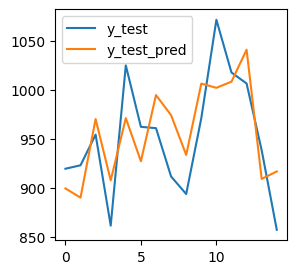

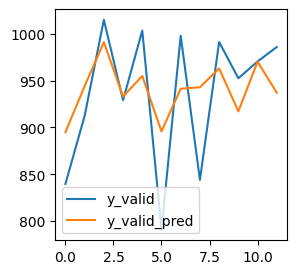

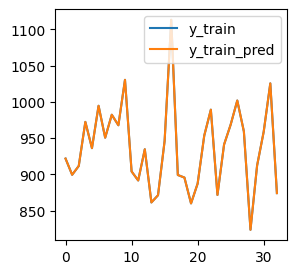

In [12]:
data_test = {'y_test': y_test.values, 'y_test_pred' :regGradBoost.predict(X_test)}
DataFrameResults_test = pd.DataFrame(data_test)
DataFrameResults_test.plot(figsize = (3,3))

data_valid = {'y_valid': y_valid.values, 'y_valid_pred' :regGradBoost.predict(X_valid)}
DataFrameResults_valid = pd.DataFrame(data_valid)
DataFrameResults_valid.plot(figsize = (3,3))
data_test = {'y_train': y_train.values, 'y_train_pred' :regGradBoost.predict(X_train)}
DataFrameResults_train = pd.DataFrame(data_test)
DataFrameResults_train.plot(figsize = (3,3))

## Homework: <font color='red'> Explain the origin of the overfitting observed above, and comment why giving the performance on the train database is erroneous.</font>

**Answer:** The overfitting comes from giving a very flexible Gradient Boosting model too much capacity for a very small training database. Each new tree is fitted to the residual errors left by the previous trees, so with 500 trees and depth 3 the model can progressively learn details and noise that belong only to the training split. In the executed result the training MSE is practically zero, while the validation and test errors are much larger. Reporting only the training performance is therefore erroneous because those observations were used to build the model; it measures memorization, not the ability to predict unseen cities.

## Evolution of error with the number of boosting trees

In [13]:
RMSE_Test,RMSE_Valid,RMSE_Train = list(),list(),list()
for n_estimators in range(10,1000,50):
    regGradBoost = GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=0.1,max_depth=3, random_state=0, loss='squared_error', subsample = 0.95)
    regGradBoost.fit(X_train, y_train)
    RMSE_Test.append(np.sqrt(mean_squared_error(y_test, regGradBoost.predict(X_test))))
    RMSE_Valid.append(np.sqrt(mean_squared_error(y_valid, regGradBoost.predict(X_valid))))
    RMSE_Train.append(np.sqrt(mean_squared_error(y_train, regGradBoost.predict(X_train))))


In [14]:
index_sliced = list(range(10, 1000, 50))[:len(RMSE_Train)]

df_RMSE_Train = pd.DataFrame(RMSE_Train, index=index_sliced, columns=['RMSE_Train'])
df_RMSE_Valid = pd.DataFrame(RMSE_Valid, index=index_sliced, columns=['RMSE_Valid'])
df_RMSE_Test = pd.DataFrame(RMSE_Test, index=index_sliced, columns=['RMSE_Test'])

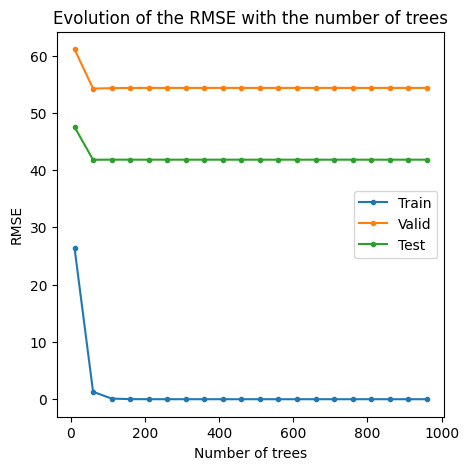

In [15]:

plt.figure(figsize=(5, 5))

# Plot each DataFrame using its index for the x-axis and the RMSE column for the y-axis
plt.plot(df_RMSE_Train.index, df_RMSE_Train['RMSE_Train'], '.-', label='Train')
plt.plot(df_RMSE_Valid.index, df_RMSE_Valid['RMSE_Valid'], '.-', label='Valid')
plt.plot(df_RMSE_Test.index, df_RMSE_Test['RMSE_Test'], '.-', label='Test')

# Set chart titles and axis labels
plt.title('Evolution of the RMSE with the number of trees')
plt.xlabel('Number of trees')
plt.ylabel('RMSE')

# Add a legend to differentiate the Train, Validation, and Test lines
plt.legend()

# Display the plot
plt.show()

In [16]:
RMSE_Test,RMSE_Valid,RMSE_Train = list(),list(),list()
for max_depth in range(1,15,1):
    regGradBoost = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1,max_depth=max_depth, random_state=0, loss='squared_error', subsample = 0.95)
    regGradBoost.fit(X_train, y_train)
    RMSE_Test.append(np.sqrt(mean_squared_error(y_test, regGradBoost.predict(X_test))))
    RMSE_Valid.append(np.sqrt(mean_squared_error(y_valid, regGradBoost.predict(X_valid))))
    RMSE_Train.append(np.sqrt(mean_squared_error(y_train, regGradBoost.predict(X_train))))

In [17]:

index_range = list(range(1, 15, 1))

# Create the DataFrames using the new index
df_RMSE_Train = pd.DataFrame(RMSE_Train, index=index_range, columns=['RMSE_Train'])
df_RMSE_Valid = pd.DataFrame(RMSE_Valid, index=index_range, columns=['RMSE_Valid'])
df_RMSE_Test = pd.DataFrame(RMSE_Test, index=index_range, columns=['RMSE_Test'])

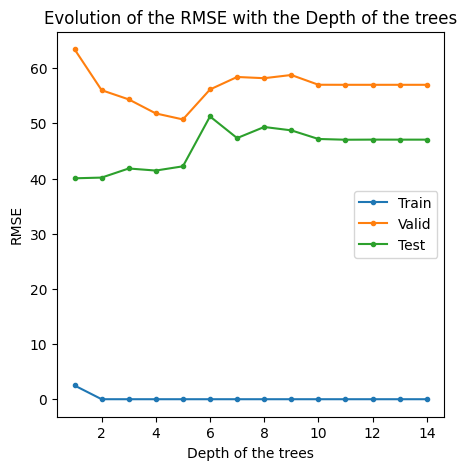

In [18]:


plt.figure(figsize=(5, 5))
plt.plot(df_RMSE_Train.index, df_RMSE_Train['RMSE_Train'], '.-', label='Train')
plt.plot(df_RMSE_Valid.index, df_RMSE_Valid['RMSE_Valid'], '.-', label='Valid')
plt.plot(df_RMSE_Test.index, df_RMSE_Test['RMSE_Test'], '.-', label='Test')
plt.title('Evolution of the RMSE with the Depth of the trees')
plt.xlabel('Depth of the trees')
plt.ylabel('RMSE')
plt.legend()
plt.show()

## Note the flattening of the curve due to overfitting!!!!!

The validation and test curves are the useful ones here. Once the number or depth of trees increases enough, the training RMSE keeps improving but the validation/test RMSE stops improving or becomes unstable. This is the practical signal that the model is no longer learning general structure; it is learning details of the training split.

# Next we will do cross validation in order to simulate unseen data better

## Explanation of Cross validation.
Taken from https://scikit-learn.org/stable/modules/cross_validation.html

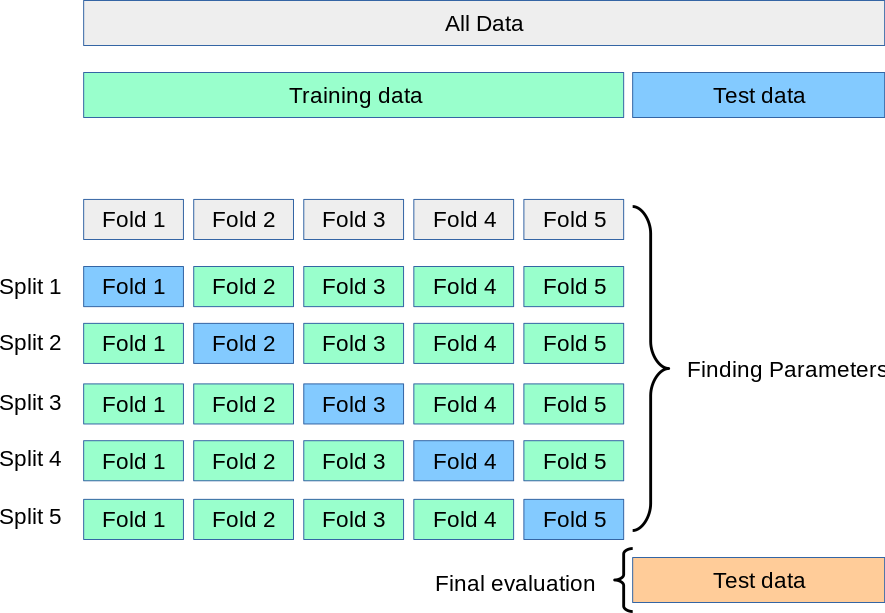

In [19]:
y = Data['MORT']
X = Data[ColumnName[:-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Let us use the implementation of cross validation in sklearn.
### Note the structure of the score
### Note the uncorrelation between test and train and the difference

In [20]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB

In [21]:
InputFeatures = [fea for fea in Data.columns if  fea != 'MORT']
print(f' Input variables: \n {InputFeatures}')

 Input variables: 
 ['PREC', 'JANT', 'JULT', 'OVR65', 'POPN', 'EDUC', 'HOUS', 'DENS', 'NONW', 'WWDRK', 'POOR', 'HC', 'NOX', 'SO', 'HUMID']


In [22]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid to test
param_grid = {
    'n_estimators': [10, 50, 100, 1000, 1500],
    'learning_rate': [0.001, 0.01, 0.1],
    'max_depth': [1, 2, 5, 10]
}

# 2. Initialize the base model
# The small subsample keeps the model close to the one used above.
gbr = GradientBoostingRegressor(
    random_state=42,
    loss='squared_error',
    subsample=0.95
)

# 3. Create GridSearchCV with 10-fold cross-validation
# The score is negative because sklearn assumes that bigger scores are better.
gbr_cv = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)

# 4. Fit the grid search using the deterministic train/test split created above
gbr_cv.fit(X_train, y_train)

# 5. Extract and display the results
best_params = gbr_cv.best_params_
best_cv_rmse = -gbr_cv.best_score_
best_reg_gbr = gbr_cv.best_estimator_

print('Optimal parameters found by cross-validation:')
print(f"  - n_estimators: {best_params['n_estimators']}")
print(f"  - learning_rate: {best_params['learning_rate']}")
print(f"  - max_depth: {best_params['max_depth']}")
print()
print(f"Best Cross-Validation RMSE: {best_cv_rmse:.2f}")

cv_results = pd.DataFrame(gbr_cv.cv_results_).sort_values('rank_test_score')
cv_summary = cv_results[
    [
        'rank_test_score',
        'param_n_estimators',
        'param_learning_rate',
        'param_max_depth',
        'mean_test_score',
        'std_test_score',
        'mean_train_score'
    ]
].head(10).copy()
cv_summary['mean_test_RMSE'] = -cv_summary['mean_test_score']
cv_summary['std_test_RMSE'] = cv_summary['std_test_score']
cv_summary['mean_train_RMSE'] = -cv_summary['mean_train_score']
cv_summary = cv_summary[
    [
        'rank_test_score',
        'param_n_estimators',
        'param_learning_rate',
        'param_max_depth',
        'mean_test_RMSE',
        'std_test_RMSE',
        'mean_train_RMSE'
    ]
]
display(cv_summary.round(2))

Optimal parameters found by cross-validation:
  - n_estimators: 50
  - learning_rate: 0.1
  - max_depth: 2

Best Cross-Validation RMSE: 38.84


,rank_test_score,param_n_estimators,param_learning_rate,param_max_depth,mean_test_RMSE,std_test_RMSE,mean_train_RMSE
46,1,50,0.10,2,38.84,19.44,9.54
47,2,100,0.10,2,39.57,19.69,3.61
48,3,1000,0.10,2,40.00,19.87,0.00
49,4,1500,0.10,2,40.00,19.87,0.00
28,5,1000,0.01,2,40.45,19.47,3.77
29,6,1500,0.01,2,40.62,19.73,1.58
52,7,100,0.10,5,41.45,18.99,0.01
53,8,1000,0.10,5,41.45,18.99,0.00
54,9,1500,0.10,5,41.45,18.99,0.00
51,10,50,0.10,5,41.46,19.01,0.63


,Split,RMSE,MSE,Num observations
0,Train,10.08,101.64,45
1,Test,34.68,1202.88,15


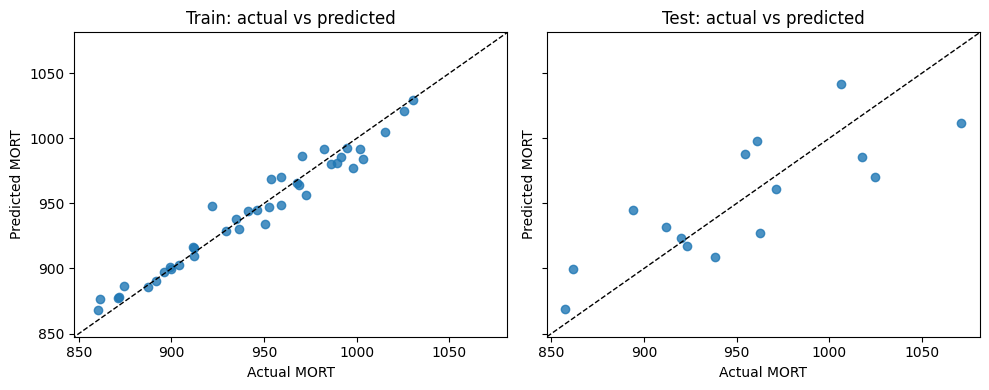

In [23]:
# Compare predictions from the selected model on train and test data.
train_predictions = best_reg_gbr.predict(X_train)
test_predictions = best_reg_gbr.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

prediction_summary = pd.DataFrame(
    {
        'Split': ['Train', 'Test'],
        'RMSE': [train_rmse, test_rmse],
        'MSE': [train_rmse**2, test_rmse**2],
        'Num observations': [len(y_train), len(y_test)]
    }
)
display(prediction_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, actual, predicted, title in [
    (axes[0], y_train, train_predictions, 'Train: actual vs predicted'),
    (axes[1], y_test, test_predictions, 'Test: actual vs predicted')
]:
    ax.scatter(actual, predicted, alpha=0.8)
    limits = [
        min(actual.min(), predicted.min()) - 10,
        max(actual.max(), predicted.max()) + 10
    ]
    ax.plot(limits, limits, 'k--', linewidth=1)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_title(title)
    ax.set_xlabel('Actual MORT')
    ax.set_ylabel('Predicted MORT')
plt.tight_layout()
plt.show()

## Let us see the relative importance of each variable.

,Feature Importance
NONW,0.3687
SO,0.1544
EDUC,0.1063
PREC,0.1041
NOX,0.0709
HOUS,0.0409
OVR65,0.0403
HC,0.0289
JANT,0.0233
WWDRK,0.0226


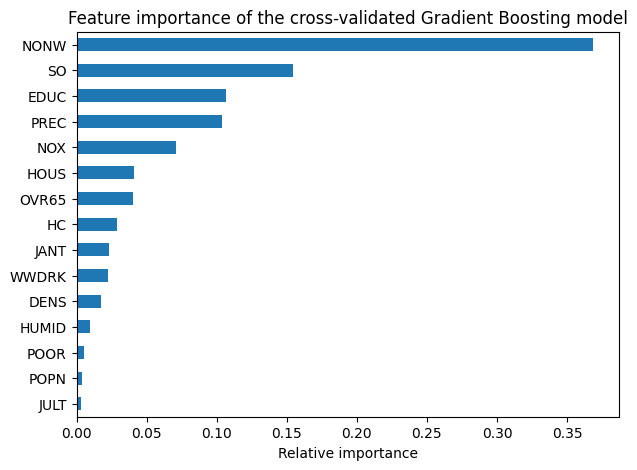

In [24]:
FeatureImportance = pd.DataFrame(
    best_reg_gbr.feature_importances_,
    columns=['Feature Importance'],
    index=InputFeatures
)
FeatureImportance.sort_values(by=['Feature Importance'], inplace=True, ascending=False)
display(FeatureImportance.round(4))

ax = FeatureImportance.sort_values(by=['Feature Importance']).plot.barh(figsize=(7, 5), legend=False)
ax.set_title('Feature importance of the cross-validated Gradient Boosting model')
ax.set_xlabel('Relative importance')
plt.show()

## Homework: <font color='red'> Give an interpretation of the plausability of the variable ranking (try a sociological explanation).</font>
## Homework: <font color='red'> Comment briefly on the difference of ranking with the decision trees.</font>
## Homework: <font color='red'> Given the ranking think of feature engineering that might improve the performance.</font>

### Answers

1. The ranking is plausible as a predictive result because the strongest variables mix social conditions and environmental exposure. `NONW` appears first, but this should be interpreted carefully: it is not a biological explanation, it is likely acting as a proxy for historical segregation, inequality, housing quality, occupation, access to services, and urban exposure. Pollution variables such as `SO` and `NOX`, together with `PREC` and climate variables, also make sense because mortality can be affected by environmental and industrial conditions. `EDUC` is plausible because education often correlates with income, health literacy, occupational exposure, and access to healthcare.

2. A single decision tree gives a hierarchy of local threshold questions. In the simple tree, `NONW` is the first split, then variables such as `OVR65`, `NOX`, `EDUC`, and `POPN` appear depending on the branch. Gradient Boosting uses many small trees, so its ranking is an average contribution over many residual corrections. This makes the boosting ranking less dependent on one early split, although it is still predictive importance and not causal importance.

3. Useful feature engineering could include `log1p(HC)`, `log1p(NOX)`, and `log1p(SO)` to reduce pollution outliers; a combined pollution index; a socioeconomic index based on `EDUC`, `HOUS`, `POOR`, `NONW`, and `WWDRK`; and interaction terms such as pollution multiplied by `DENS` or `POOR`. These features should be tested by cross-validation because the dataset is small and it is easy to overfit.

 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear. Put both the infographic and the prompt here. The infographic should include the final final results.

**Prompt used for generation:** Create a clean academic infographic titled "Gradient Boosting for Pollution Mortality Prediction". Use a white background with blue, green, red, and purple accents. Include compact sections for the pollution mortality dataset, the workflow, the overfitting signal, the cross-validation result, feature importance, prediction quality, and final recommendations. Include the final executed results: 60 observations, 15 input variables, target `MORT`, baseline Gradient Boosting train RMSE near 0, validation RMSE about 54.34, test RMSE about 41.82, best cross-validated model with `learning_rate=0.1`, `max_depth=2`, `n_estimators=50`, CV RMSE 38.84, train RMSE 10.08, and test RMSE 34.68. Highlight the top features `NONW`, `SO`, `EDUC`, `PREC`, and `NOX`. Emphasize that feature importance is predictive, not causal, and that the small dataset requires cross-validation and cautious interpretation.

The infographic below is generated directly from the current notebook variables, so the numbers match the executed results.

**Infographic generated from the current notebook results:**

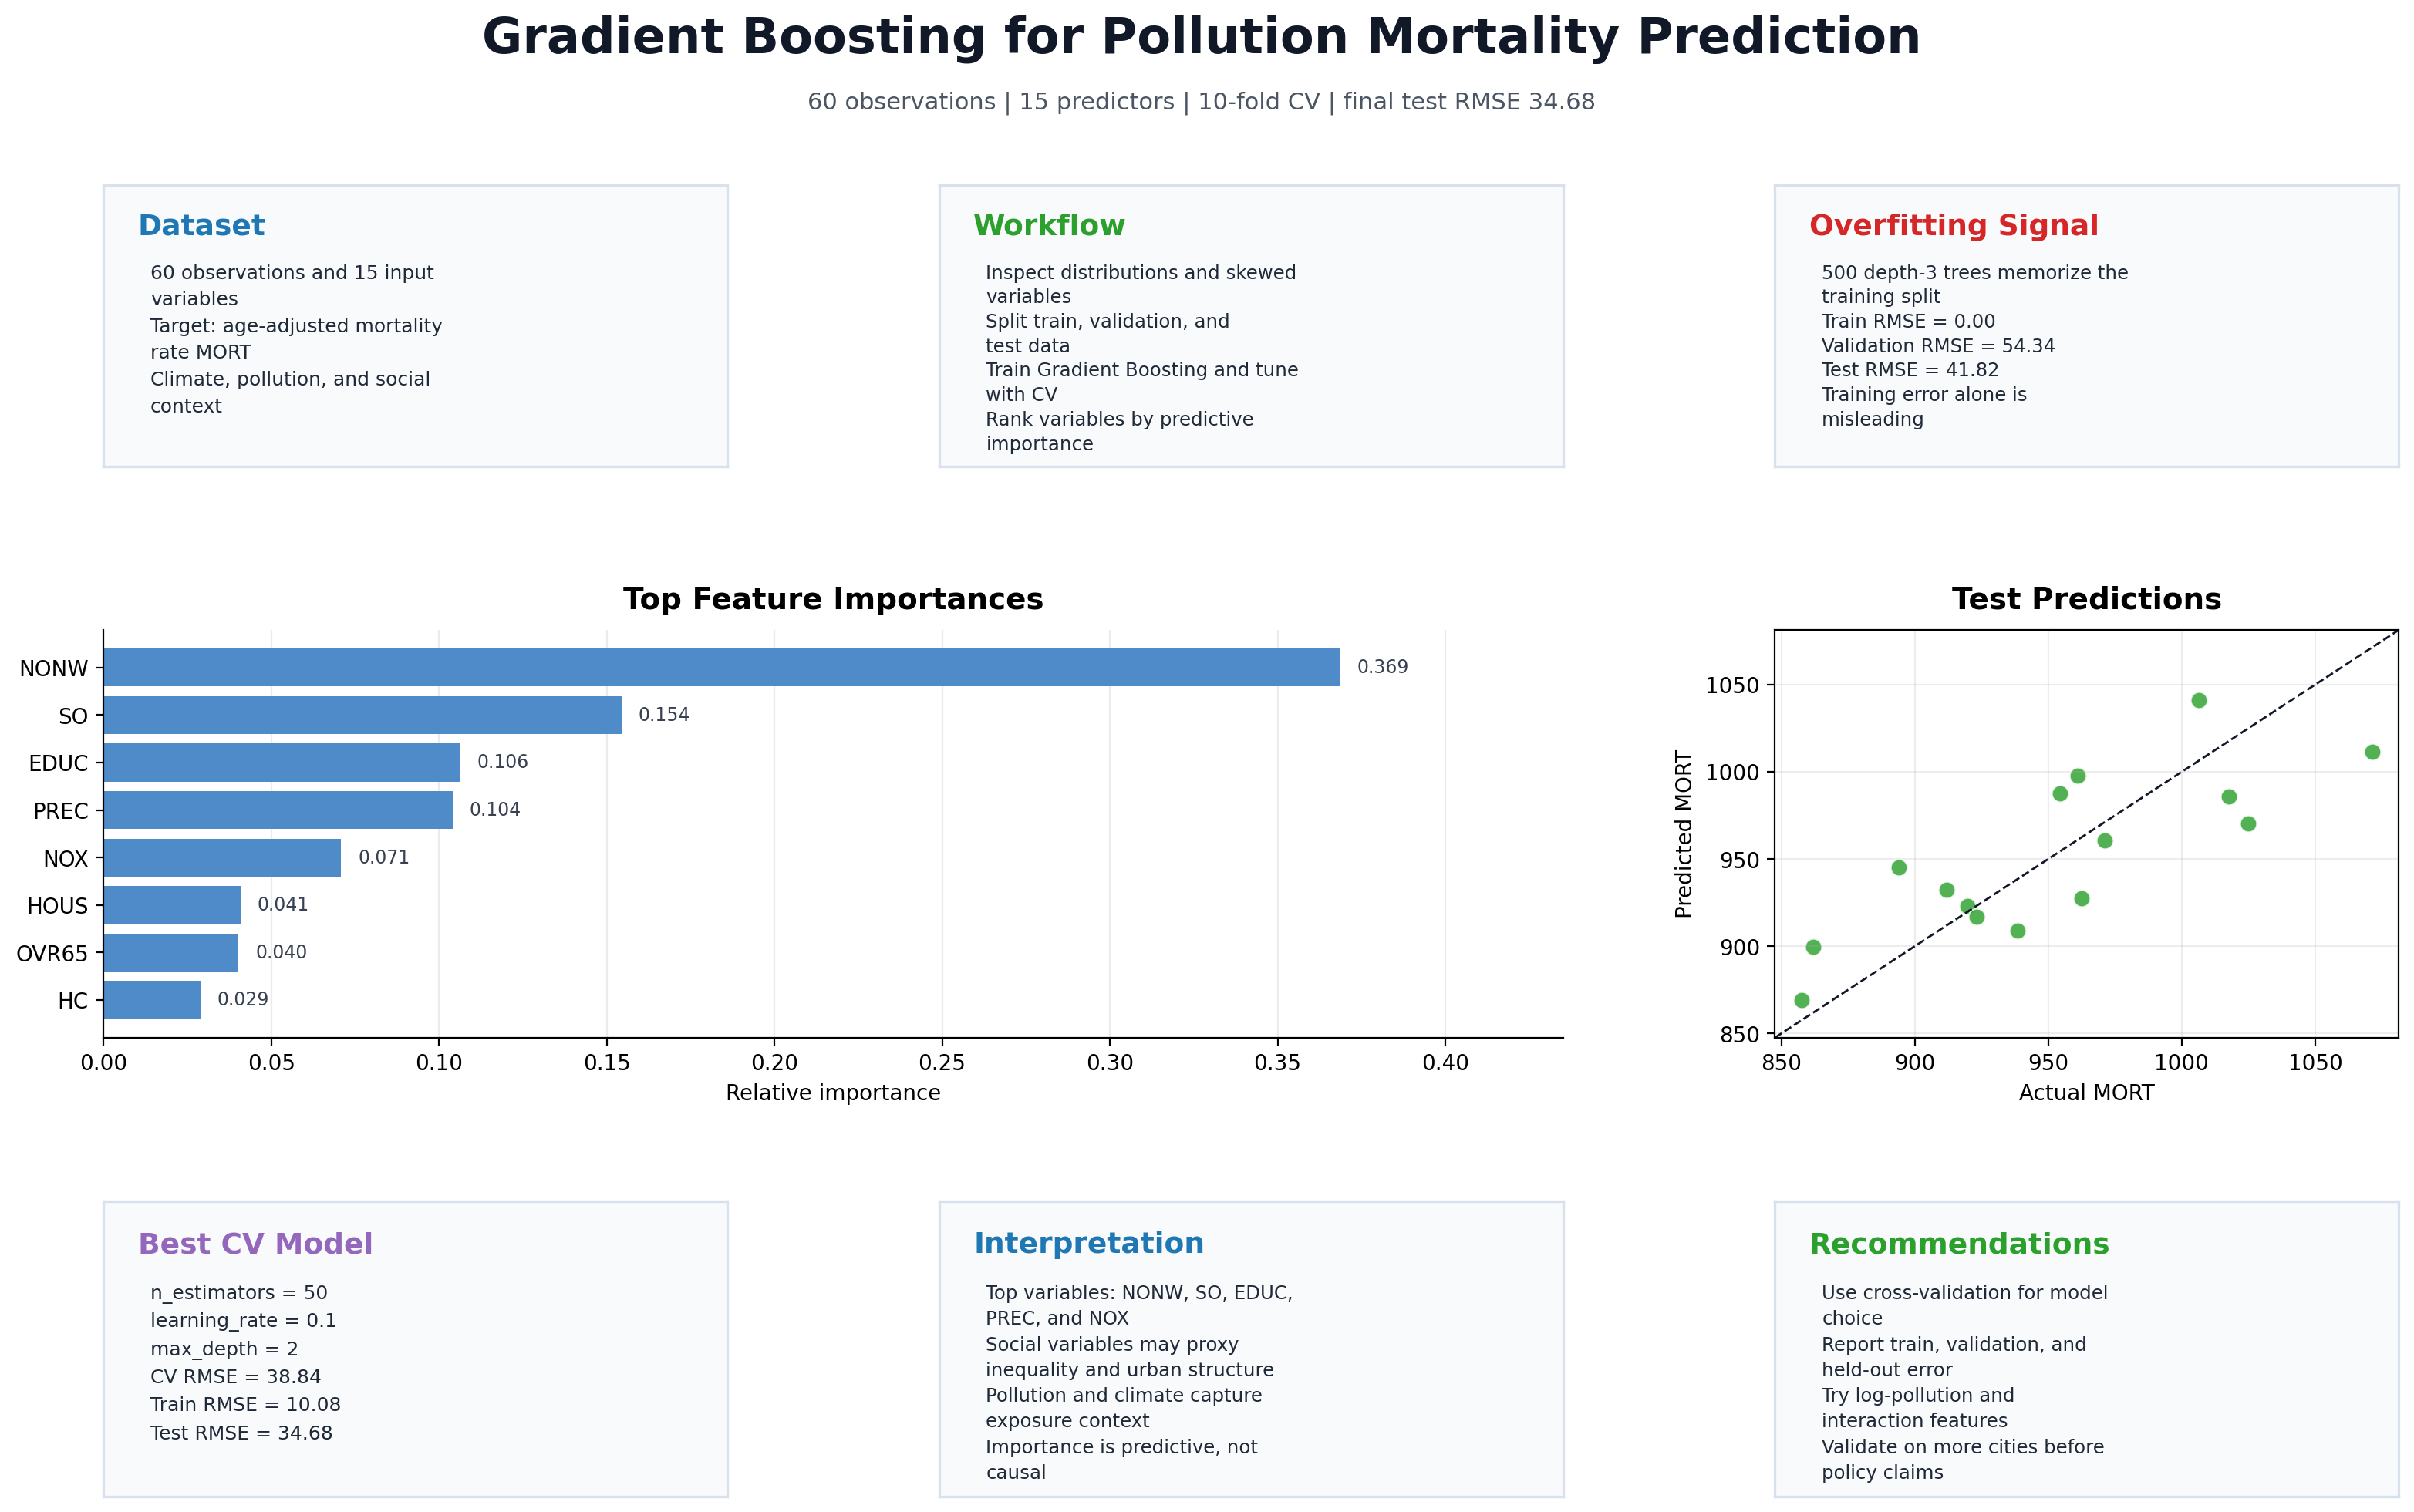

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.

### Executive report

This practice studied the pollution mortality dataset with Gradient Boosting regression. The target was `MORT`, the total age-adjusted mortality rate, and the predictors combined climate, demographic, socioeconomic, and pollution variables. The exploratory analysis showed a small dataset with heterogeneous scales and several strongly skewed variables, especially the pollution measures.

The first Gradient Boosting model, with 500 trees and depth 3, clearly overfits: the train error is almost zero, while the validation and test errors are much larger. This shows why train performance is not a reliable measure of generalization. The cross-validated search selected a more controlled model with `learning_rate=0.1`, `max_depth=2`, and `n_estimators=50`. Its mean cross-validation RMSE is **38.84** and its held-out test RMSE is **34.68**, which improves the first overfitted model's test RMSE of about **41.82**.

The most important variables in the final model are `NONW`, `SO`, `EDUC`, `PREC`, and `NOX`. This ranking is plausible as a predictive pattern because it combines social structure, pollution exposure, education, and climate. However, it must not be interpreted as proof of causality. Variables such as `NONW` can represent historical and socioeconomic context, so the model should be read carefully and ethically.

The main challenges are the small number of observations, the skewed pollution variables, and the risk of finding unstable patterns. A better solution would use repeated cross-validation, compare Gradient Boosting with regularized linear regression and Random Forests, test engineered variables such as log-pollution and socioeconomic indexes, and validate the conclusions on a larger or external dataset before making policy claims.